# 01 — Pulling and mapping GBIF occurrence data

Pull red squirrel (*Sciurus vulgaris*) occurrence records from GBIF for Aberdeenshire and map.

This has presence-only sampling bias; the database reflects where people go, not where the species lives. Any model trained naively on this data learns observer behaviour as much as species ecology.

In [1]:
from dotenv import load_dotenv
import os
import time
import sqlite3

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pygbif import species as gbif_species
from pygbif import occurrences


In [2]:
load_dotenv()

GBIF_USER  = os.environ['GBIF_USER']
GBIF_PWD   = os.environ['GBIF_PWD']
GBIF_EMAIL = os.environ['GBIF_EMAIL']

print(f'Authenticated as: {GBIF_USER}')


Authenticated as: deonroos


## 1. Find the GBIF taxon key

Every taxon in GBIF has a unique integer key. Look it up by scientific name.

In [3]:
match     = gbif_species.name_backbone(scientificName='Sciurus vulgaris', taxonRank='species')
taxon_key = int(match['usage']['key'])

print(f"Sciurus vulgaris  ->  taxon key {taxon_key}")
print(f"Match type: {match['diagnostics']['matchType']},  Confidence: {match['diagnostics']['confidence']}")


Sciurus vulgaris  ->  taxon key 8211070
Match type: EXACT,  Confidence: 99


## 2. Pull occurrence records for Aberdeenshire

Use a bounding box covering Aberdeenshire and pull only georeferenced records without known spatial issues.

In [4]:
# Aberdeenshire bounding box (longitude latitude, in proj WGS84)
BBOX = 'POLYGON((-3.7 56.85,-1.75 56.85,-1.75 57.75,-3.7 57.75,-3.7 56.85))'

records = []
limit   = 300
offset  = 0

while True:
    batch = occurrences.search(
        taxonKey           = taxon_key,
        geometry           = BBOX,
        hasCoordinate     = True,
        hasGeospatialIssue = False,
        limit              = limit,
        offset             = offset,
    )
    records.extend(batch['results'])
    print(f"  {len(records):>6,} / {batch['count']:,}")
    if batch['endOfRecords']:
        break
    offset += limit
    time.sleep(0.3)

print(f'\nFetch complete: {len(records):,} records.')


     300 / 34,866
     600 / 34,866
     900 / 34,866
   1,200 / 34,866
   1,500 / 34,866
   1,800 / 34,866
   2,100 / 34,866
   2,400 / 34,866
   2,700 / 34,866
   3,000 / 34,866
   3,300 / 34,866
   3,600 / 34,866
   3,900 / 34,866
   4,200 / 34,866
   4,500 / 34,866
   4,800 / 34,866
   5,100 / 34,866
   5,400 / 34,866
   5,700 / 34,866
   6,000 / 34,866
   6,300 / 34,866
   6,600 / 34,866
   6,900 / 34,866
   7,200 / 34,866
   7,500 / 34,866
   7,800 / 34,866
   8,100 / 34,866
   8,400 / 34,866
   8,700 / 34,866
   9,000 / 34,866
   9,300 / 34,866
   9,600 / 34,866
   9,900 / 34,866
  10,200 / 34,866
  10,500 / 34,866
  10,800 / 34,866
  11,100 / 34,866
  11,400 / 34,866
  11,700 / 34,866
  12,000 / 34,866
  12,300 / 34,866
  12,600 / 34,866
  12,900 / 34,866
  13,200 / 34,866
  13,500 / 34,866
  13,800 / 34,866
  14,100 / 34,866
  14,400 / 34,866
  14,700 / 34,866
  15,000 / 34,866
  15,300 / 34,866
  15,600 / 34,866
  15,900 / 34,866
  16,200 / 34,866
  16,500 / 34,866
  16,800 /

In [5]:
df = pd.DataFrame(records)

keep = [
    'decimalLatitude', 'decimalLongitude',
    'year', 'month', 'basisOfRecord',
    'datasetName', 'coordinateUncertaintyInMeters',
]
keep = [c for c in keep if c in df.columns]
df   = df[keep].dropna(subset=['decimalLatitude', 'decimalLongitude']).copy()

print(df.shape)
df.head()


(34866, 7)


,decimalLatitude,decimalLongitude,year,month,basisOfRecord,datasetName,coordinateUncertaintyInMeters
0,57.170155,-2.099028,2026.0,1.0,HUMAN_OBSERVATION,iNaturalist research-grade observations,8.0
1,56.984531,-3.468660,2026.0,1.0,HUMAN_OBSERVATION,The Scottish Squirrel Database,100.0
2,57.195499,-2.115150,2026.0,1.0,HUMAN_OBSERVATION,The Scottish Squirrel Database,100.0
3,57.653980,-3.341850,2026.0,1.0,HUMAN_OBSERVATION,The Scottish Squirrel Database,100.0
4,57.100510,-2.451430,2026.0,1.0,HUMAN_OBSERVATION,The Scottish Squirrel Database,70.7


## 3. Save to SQLite

Raw data into a local SQLite database. Database file is gitignored.

In [6]:
os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)

DB_PATH = 'data/gbif_records.db'

with sqlite3.connect(DB_PATH) as conn:
    df.to_sql('red_squirrel', conn, if_exists='replace', index=False)

print(f'Saved {len(df):,} records to {DB_PATH}')


Saved 34,866 records to data/gbif_records.db


## 4. What do we have?

In [7]:
print(f'Records:    {len(df):,}')
print(f"Year range: {int(df['year'].min())} to {int(df['year'].max())}")
print()
print('Basis of record:')
print(df['basisOfRecord'].value_counts().to_string())


Records:    34,866
Year range: 1893 to 2026

Basis of record:
basisOfRecord
HUMAN_OBSERVATION      28955
MATERIAL_SAMPLE         5678
MACHINE_OBSERVATION      221
PRESERVED_SPECIMEN        12


## 5. Map the records

The left panel shows raw occurrence points. The right shows sampling density as a hexbin grid. Clusters likely show observer effort, not species abundance.

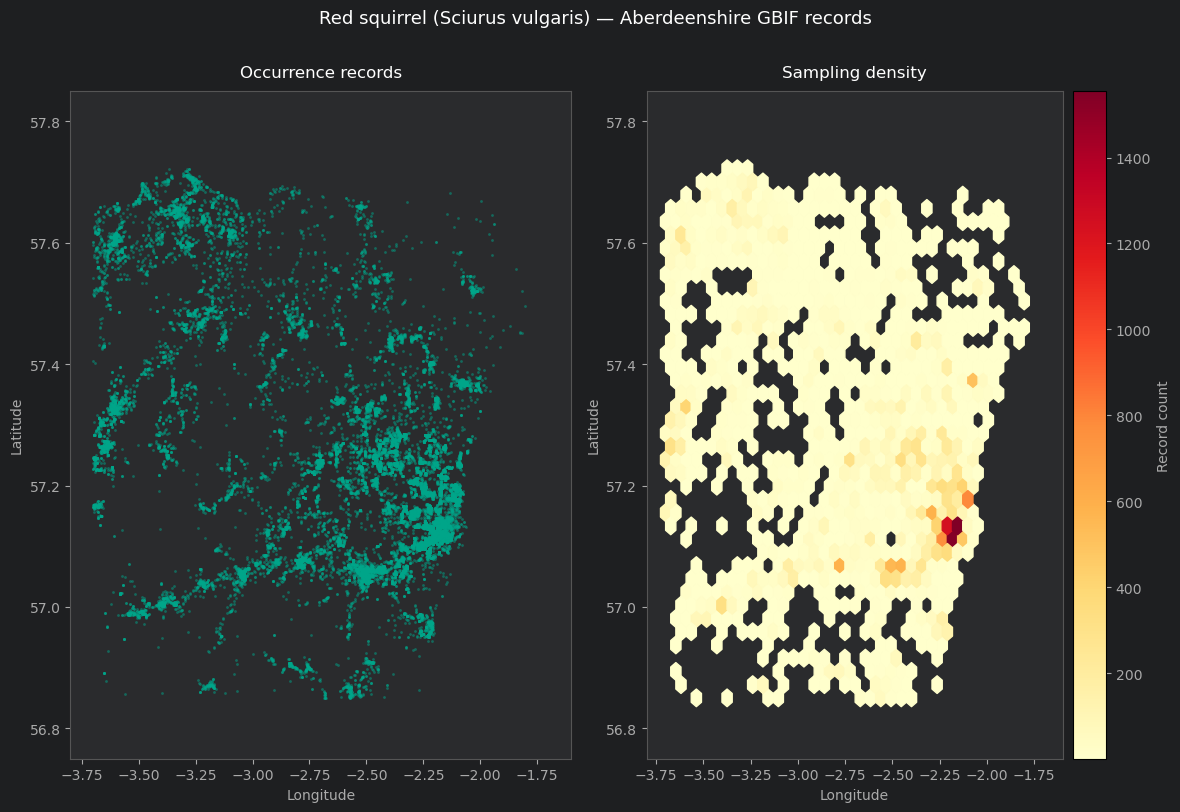

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 8), facecolor='#1e1f21')

for ax in axes:
    ax.set_facecolor('#2a2b2d')
    ax.tick_params(colors='#aaa')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')
    ax.set_xlim(-3.8, -1.6)
    ax.set_ylim(56.75, 57.85)
    ax.set_xlabel('Longitude', color='#aaa')
    ax.set_ylabel('Latitude',  color='#aaa')

axes[0].scatter(
    df['decimalLongitude'], df['decimalLatitude'],
    s=4, alpha=0.5, color='#00a68a', linewidths=0,
)
axes[0].set_title('Occurrence records', color='white', pad=10)

hb = axes[1].hexbin(
    df['decimalLongitude'], df['decimalLatitude'],
    gridsize=35, cmap='YlOrRd', mincnt=1,
)
cb = fig.colorbar(hb, ax=axes[1], pad=0.02)
cb.ax.yaxis.set_tick_params(color='#aaa')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaa')
cb.set_label('Record count', color='#aaa')
axes[1].set_title('Sampling density', color='white', pad=10)

fig.suptitle(
    'Red squirrel (Sciurus vulgaris) — Aberdeenshire GBIF records',
    color='white', y=1.01, fontsize=13,
)
plt.tight_layout()
plt.savefig('figures/01_occurrences_map.png', dpi=150,
            bbox_inches='tight', facecolor='#1e1f21')
plt.show()


## What the map tells us

The density plot makes the bias visible. High-density cells correspond to Aberdeen city, the Deeside corridor, and sites near main roads — not because red squirrels are especially abundant there, but because these are places people visit and submit records.

This is the core problem: the training data for any SDM fitted to these records is a sample of human behaviour, not a census of the species. The next notebook addresses this through pseudo-absence generation strategies.